In [1]:
pip install activecampaign

Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import numpy as np
import statsmodels.api as sm
import requests

# Set your API credentials
API_URL = 'https://umd213.api-us1.com/api/3/'  # <-- Your base API URL
API_KEY = '2e171eb87de79da990080e792486427c2d35b5f256b77e2fe24f9afb2364a754416288c4'

# Common headers
HEADERS = {
    'Api-Token': API_KEY,
    'Content-Type': 'application/json'
}

# Function to fetch campaigns
def get_campaigns():
    url = API_URL + 'campaigns'
    response = requests.get(url, headers=HEADERS)

    if response.status_code == 200:
        campaigns = response.json()['campaigns']
        return pd.DataFrame(campaigns)
    else:
        print(f"Error {response.status_code}: {response.text}")
        return None

# Fetch and display campaigns
campaigns_df = get_campaigns()
if campaigns_df is not None:
    print("Campaigns fetched:")
    print(campaigns_df[['name', 'cdate', 'opens', 'uniqueopens', 'linkclicks', 'uniquelinkclicks', 'unsubscribes']].head()
)

Campaigns fetched:
                            name                      cdate opens uniqueopens  \
0       Terps Esports Newsletter  2025-04-25T20:16:18-05:00     2           1   
1          Terps Newsletter Test  2025-04-25T20:20:21-05:00    20           3   
2  Terps - Recwell Icecream Day   2025-04-25T20:40:07-05:00     2           2   

  linkclicks uniquelinkclicks unsubscribes  
0          0                0            0  
1          8                8            0  
2          0                0            0  


In [6]:
campaigns_df['cdate'] = pd.to_datetime(campaigns_df['cdate'])
campaigns_df = campaigns_df.sort_values('cdate')
campaigns_df[['name', 'cdate', 'opens', 'uniqueopens', 'linkclicks', 'uniquelinkclicks', 'unsubscribes']]

,name,cdate,opens,uniqueopens,linkclicks,uniquelinkclicks,unsubscribes
0,Terps Esports Newsletter,2025-04-25 20:16:18-05:00,2,1,0,0,0
1,Terps Newsletter Test,2025-04-25 20:20:21-05:00,20,3,8,8,0
2,Terps - Recwell Icecream Day,2025-04-25 20:40:07-05:00,2,2,0,0,0


In [7]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

def simulate_email_data_spikey():
    """
    Simulates realistic email data with weekly patterns:
    - Higher engagement on weekdays (especially mid-week)
    - Lower engagement on weekends
    """
    # Email Titles
    names = [
        'Newsletter', 'Promo Blast', 'Weekly Update', 'Work Reminder',
        '🔥 Career Hack Alert', 'UMD RecWell Notice', '50% Pro Discount',
        'Free Fries Friday', 'Job Alerts', 'AI Tips Newsletter'
    ]

    # Date Range: Past 30 days
    end_date = datetime.now()
    date_range = pd.date_range(end=end_date, periods=30)

    simulated_rows = []

    for date in date_range:
        weekday = date.weekday()  # 0 = Monday, 6 = Sunday

        # Engagement base scaling
        if weekday < 5:
            open_mean = 150 + np.random.randint(0, 50)  # Weekdays higher
        else:
            open_mean = 60 + np.random.randint(0, 20)   # Weekends lower

        for name in names:
            opens = np.random.poisson(lam=open_mean)
            unique_opens = max(0, int(opens * np.random.uniform(0.5, 0.8)))
            clicks = max(0, int(opens * np.random.uniform(0.2, 0.4)))
            unique_clicks = max(0, int(clicks * np.random.uniform(0.5, 0.9)))
            unsubscribes = np.random.binomial(n=3, p=0.05)  # usually low

            simulated_rows.append({
                'name': name,
                'cdate': date,
                'opens': opens,
                'uniqueopens': unique_opens,
                'linkclicks': clicks,
                'uniquelinkclicks': unique_clicks,
                'unsubscribes': unsubscribes
            })

    simulated_df = pd.DataFrame(simulated_rows)
    simulated_df['cdate'] = pd.to_datetime(simulated_df['cdate'])
    return simulated_df

# Example usage
spikey_df = simulate_email_data_spikey()
spikey_df.head()

,name,cdate,opens,uniqueopens,linkclicks,uniquelinkclicks,unsubscribes
0,Newsletter,2025-03-28 04:16:45.227238,179,100,52,40,0
1,Promo Blast,2025-03-28 04:16:45.227238,191,117,65,47,0
2,Weekly Update,2025-03-28 04:16:45.227238,216,162,56,39,0
3,Work Reminder,2025-03-28 04:16:45.227238,200,109,68,41,0
4,🔥 Career Hack Alert,2025-03-28 04:16:45.227238,187,113,44,32,1


In [8]:
# Step 1: Remove timezone from real data
campaigns_df['cdate'] = pd.to_datetime(campaigns_df['cdate']).dt.tz_localize(None)

# Step 2: Merge real and simulated
combined_df = pd.concat([campaigns_df, spikey_df], ignore_index=True)

# Step 3: Sort and Save
combined_df = combined_df.sort_values(by=['cdate'])
combined_df.to_csv("combined_campaign_data.csv", index=False)

print("Merged dataset saved to combined_campaign_data.csv")

# Step 4: View few records
print(combined_df[['name', 'cdate', 'opens', 'uniqueopens', 'linkclicks', 'uniquelinkclicks', 'unsubscribes']].head())
combined_df.info()

Merged dataset saved to combined_campaign_data.csv
                   name                      cdate opens uniqueopens  \
12   AI Tips Newsletter 2025-03-28 04:16:45.227238   215         125   
11           Job Alerts 2025-03-28 04:16:45.227238   199         122   
9      50% Pro Discount 2025-03-28 04:16:45.227238   184         111   
8    UMD RecWell Notice 2025-03-28 04:16:45.227238   200         148   
7   🔥 Career Hack Alert 2025-03-28 04:16:45.227238   187         113   

   linkclicks uniquelinkclicks unsubscribes  
12         73               40            0  
11         42               37            0  
9          42               33            0  
8          59               45            0  
7          44               32            1  
<class 'pandas.core.frame.DataFrame'>
Index: 303 entries, 12 to 302
Columns: 110 entries, type to automation
dtypes: datetime64[ns](1), object(109)
memory usage: 262.8+ KB


In [9]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
    print(combined_df[['name', 'cdate', 'opens', 'uniqueopens', 'linkclicks', 'uniquelinkclicks', 'unsubscribes']])

                              name                      cdate opens  \
12              AI Tips Newsletter 2025-03-28 04:16:45.227238   215   
11                      Job Alerts 2025-03-28 04:16:45.227238   199   
9                 50% Pro Discount 2025-03-28 04:16:45.227238   184   
8               UMD RecWell Notice 2025-03-28 04:16:45.227238   200   
7              🔥 Career Hack Alert 2025-03-28 04:16:45.227238   187   
6                    Work Reminder 2025-03-28 04:16:45.227238   200   
10               Free Fries Friday 2025-03-28 04:16:45.227238   166   
4                      Promo Blast 2025-03-28 04:16:45.227238   191   
3                       Newsletter 2025-03-28 04:16:45.227238   179   
5                    Weekly Update 2025-03-28 04:16:45.227238   216   
22              AI Tips Newsletter 2025-03-29 04:16:45.227238    66   
19                50% Pro Discount 2025-03-29 04:16:45.227238    70   
21                      Job Alerts 2025-03-29 04:16:45.227238    71   
13    

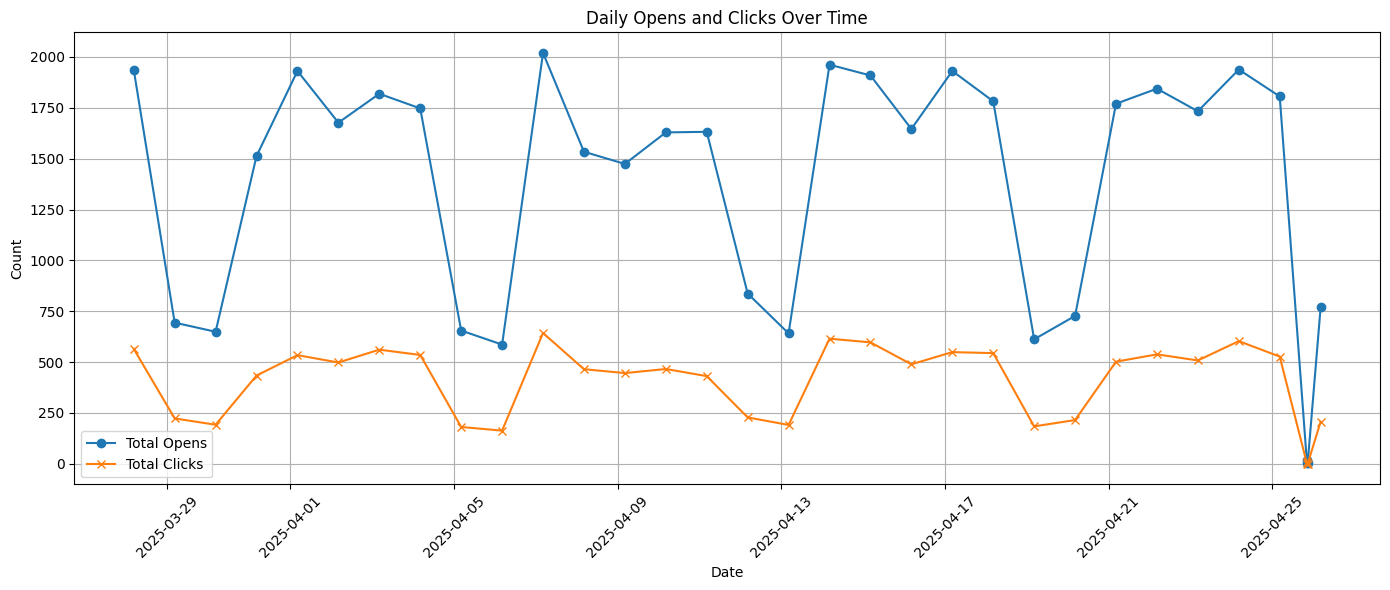

In [10]:
import matplotlib.pyplot as plt

# Group by date
daily_summary = combined_df.groupby('cdate').agg({
    'opens': 'sum',
    'uniqueopens': 'sum',
    'linkclicks': 'sum',
    'uniquelinkclicks': 'sum',
    'unsubscribes': 'sum'
})

# Plot opens and clicks
plt.figure(figsize=(14, 6))
plt.plot(daily_summary.index, daily_summary['opens'], label='Total Opens', marker='o')
plt.plot(daily_summary.index, daily_summary['linkclicks'], label='Total Clicks', marker='x')
plt.title('Daily Opens and Clicks Over Time')
plt.xlabel('Date')
plt.ylabel('Count')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()